# Regresión Lineal: Exposición Detallada con Python

## Una guía paso a paso para entender y aplicar la regresión lineal simple

**Autor:** [Carlos Eduardo Reyes Barja]  
**Fecha:** [03/02/2026]



## 1. Introducción a la Regresión Lineal

La **regresión lineal** es una técnica estadística que estudia la relación entre una variable dependiente (Y) y una o más variables independientes (X). En su forma más simple, con una sola variable independiente, se denomina **regresión lineal simple**.

### Objetivos principales

- **Explicar** cómo cambia Y cuando varía X.
- **Predecir** el valor de Y para nuevos valores de X.

### Ejemplos cotidianos

- Predecir el peso de una persona (Y) a partir de su altura (X).
- Estimar las ventas de un producto (Y) en función de la inversión en publicidad (X).
- Relacionar las horas de estudio (X) con la calificación obtenida (Y).

La idea fundamental es encontrar la **recta que mejor se ajuste** a una nube de puntos. Esa recta nos permitirá hacer predicciones.




## 2. Conceptos Clave

Antes de profundizar, definamos algunos términos esenciales:

- **Variable independiente (X)**: También llamada *predictora*, *explicativa* o *regresor*. Es la variable que usamos para hacer predicciones.
- **Variable dependiente (Y)**: También llamada *respuesta* o *variable de salida*. Es lo que queremos predecir o explicar.
- **Relación lineal**: Cuando los puntos tienden a alinearse alrededor de una línea recta.
- **Error o residuo**: La diferencia entre el valor real de Y y el valor predicho por la recta. Siempre hay algo de error porque la realidad no es perfectamente lineal.



## 3. La Ecuación de la Recta de Regresión

La relación lineal entre X e Y se expresa mediante la ecuación:

$$
Y = \beta_0 + \beta_1 X + \varepsilon
$$

Donde:

- $\beta_0$ es el **intercepto** (o constante): el valor de Y cuando X = 0.
- $\beta_1$ es la **pendiente**: el cambio esperado en Y por cada incremento de una unidad en X.
- $\varepsilon$ es el **término de error**: la parte de Y que no puede explicarse mediante la relación lineal con X.

### Interpretación de los coeficientes

- Si $\beta_1 > 0$, la relación es **positiva**: al aumentar X, Y tiende a aumentar.
- Si $\beta_1 < 0$, la relación es **negativa**: al aumentar X, Y tiende a disminuir.
- Si $\beta_1 = 0$, no hay relación lineal (la recta es horizontal).



## 4. El Método de Mínimos Cuadrados Ordinarios (MCO)

¿Cómo encontramos los valores de $\beta_0$ y $\beta_1$ que mejor se ajustan a los datos? El método más común es el de **mínimos cuadrados**.

### Idea intuitiva

Queremos una recta que haga que los errores (distancias verticales entre los puntos reales y la recta) sean lo más pequeños posible. Pero si sumamos los errores directamente, los positivos y negativos se cancelarían. Por eso, los **elevamos al cuadrado** (para que todos sean positivos) y luego los sumamos. Esta suma se llama **Suma de Cuadrados de los Errores (SCE)** o **Suma de Cuadrados Residual (RSS)**.

Buscamos los $\beta_0$ y $\beta_1$ que minimicen:

$$
SCE = \sum_{i=1}^{n} (Y_i - \hat{Y}_i)^2 = \sum_{i=1}^{n} (Y_i - (\beta_0 + \beta_1 X_i))^2
$$



### Derivación matemática (para los curiosos)

Para minimizar la SCE, derivamos parcialmente con respecto a $\beta_0$ y $\beta_1$ e igualamos a cero. Obtenemos las llamadas **ecuaciones normales**:

$$
\sum Y_i = n\beta_0 + \beta_1 \sum X_i
$$

$$
\sum X_i Y_i = \beta_0 \sum X_i + \beta_1 \sum X_i^2
$$

Resolviendo, se llega a las fórmulas:

$$
\beta_1 = \frac{\sum (X_i - \bar{X})(Y_i - \bar{Y})}{\sum (X_i - \bar{X})^2}
$$
$$
\beta_0 = \bar{Y} - \beta_1 \bar{X}
$$

Donde $\bar{X}$ y $\bar{Y}$ son las medias muestrales de X e Y.

### Intuición de las fórmulas

- $\beta_1$ es como la **covarianza** entre X e Y dividida por la **varianza** de X. Mide cuánto varían conjuntamente X e Y en relación a la variabilidad propia de X.
- $\beta_0$ ajusta la recta para que pase por el punto medio $\bar{X}, \bar{Y}$.



## 5. Implementación en Python: Datos de Ejemplo

Vamos a generar datos sintéticos que sigan una tendencia lineal con algo de ruido, para ilustrar todo el proceso.

### Librerias utilizadas
- **NumPy (`import numpy as np`)**: Proporciona funciones matemáticas y manejo de arreglos multidimensionales. Lo usaremos para generar datos y operaciones numéricas.
- **Matplotlib (`import matplotlib.pyplot as plt`)**: Biblioteca para crear gráficos y visualizaciones. Nos permitirá dibujar los datos y la recta de regresión.
- **Pandas (`import pandas as pd`)**: Facilita la manipulación y análisis de datos estructurados (tablas). Aunque en este ejemplo no lo usaremos mucho, es estándar en análisis de datos.
- **Scikit-learn (`from sklearn.linear_model import LinearRegression` y `from sklearn.metrics import r2_score`)**: Librería de machine learning. `LinearRegression` implementa el modelo de regresión lineal y `r2_score` calcula el coeficiente de determinación.

In [547]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

np.random.seed(42)

X = np.linspace(0, 10, 100).reshape(-1, 1)

# Relación lineal verdadera: Y = 3 + 2*X (coeficientes reales)
# Añadimos ruido normal con media 0 y desviación 2
error = np.random.normal(0, 2, size=(100, 1))
Y = 3 + 2 * X + error


## 6. Visualización de los Datos

Siempre es recomendable graficar los datos antes de ajustar ningún modelo. Esto nos permite:
- Observar si la relación parece lineal.
- Detectar posibles valores atípicos.
- Tener una idea de la pendiente y la dispersión.

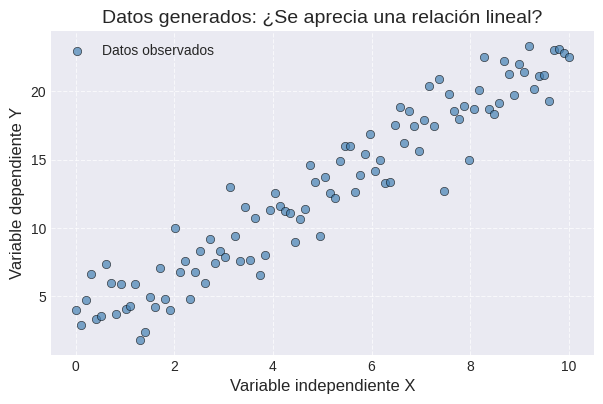

In [548]:
plt.figure(figsize=(10*7/10, 6*7/10))
plt.scatter(X, Y, color='steelblue', alpha=0.7, edgecolors='k', 
            linewidth=0.5, 
            label='Datos observados')
plt.xlabel('Variable independiente X', fontsize=12)
plt.ylabel('Variable dependiente Y', fontsize=12)
plt.title('Datos generados: ¿Se aprecia una relación lineal?', 
          fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 7. Ajuste del Modelo con Mínimos Cuadrados

Usaremos la clase `LinearRegression` de scikit-learn, que implementa mínimos cuadrados de forma eficiente. También podríamos calcular los coeficientes manualmente con las fórmulas anteriores para practicar.

In [549]:
modelo = LinearRegression()

modelo.fit(X, Y)

beta_0 = modelo.intercept_[0]
beta_1 = modelo.coef_[0][0]

print(f"Intercepto (β₀) estimado: {beta_0:.4f}")
print(f"Pendiente (β₁) estimada:   {beta_1:.4f}")
print(f"Ecuación ajustada: Y = {beta_0:.4f} + {beta_1:.4f} * X")

print("\nValores reales usados para generar los datos:")
print("β₀ real = 3, β₁ real = 2")
print("""
El método de mínimos cuadrados recupera aproximadamente 
esos valores, gracias a que el ruido tiene media cero.
      """)

Intercepto (β₀) estimado: 2.6544
Pendiente (β₁) estimada:   2.0276
Ecuación ajustada: Y = 2.6544 + 2.0276 * X

Valores reales usados para generar los datos:
β₀ real = 3, β₁ real = 2

El método de mínimos cuadrados recupera aproximadamente 
esos valores, gracias a que el ruido tiene media cero.
      


## 8. Cálculo Manual de los Coeficientes (Opcional)

Para comprender mejor las fórmulas, podemos calcular $\beta_1$ y $\beta_0$ manualmente usando NumPy.



$$
\beta_1 = \frac{\sum (X_i - \bar{X})(Y_i - \bar{Y})}{\sum (X_i - \bar{X})^2}
$$
$$
\beta_0 = \bar{Y} - \beta_1 \bar{X}
$$

In [ ]:
X_flat = X.flatten()
Y_flat = Y.flatten()
X_mean = np.mean(X_flat)
Y_mean = np.mean(Y_flat)
numerador = np.sum((X_flat - X_mean) * (Y_flat - Y_mean))
denominador = np.sum((X_flat - X_mean)**2)
beta_1_manual = numerador / denominador
beta_0_manual = Y_mean - beta_1_manual * X_mean
print(f"β₀ manual: {beta_0_manual:.4f}")
print(f"β₁ manual: {beta_1_manual:.4f}")
print("""
Coinciden con los obtenidos por scikit-learn 
(pequeñas diferencias por redondeo).""")

β₀ manual: 2.6544
β₁ manual: 2.0276

Coinciden con los obtenidos por scikit-learn 
(pequeñas diferencias por redondeo).


## 9. Interpretación de los Coeficientes Obtenidos

- **Pendiente (β₁) = 2.0276**: Por cada unidad que aumenta X, Y aumenta en promedio 2.04 unidades. En nuestro caso, por cada año de antigüedad (si X fuera años), el precio aumentaría 2.04 miles de bs (si Y fuera precio), etc. Ojo con las unidades.

- **Intercepto (β₀) = 2.6544**: Cuando X = 0, el valor esperado de Y es 2.92. Esto puede tener o no sentido dependiendo del contexto. Por ejemplo, si X son horas de estudio, X=0 sería un estudiante que no estudia, y su nota esperada sería 2.92 (sobre 10, por ejemplo). En este caso, como generamos los datos con β₀=3, tiene sentido.

Es importante recordar que estos coeficientes son **estimaciones** basadas en la muestra. Si tomáramos otra muestra, obtendríamos valores ligeramente diferentes.



## 10. La Recta de Regresión: Visualización

Ahora dibujamos la recta estimada junto con los datos originales para ver qué tan bien se ajusta.

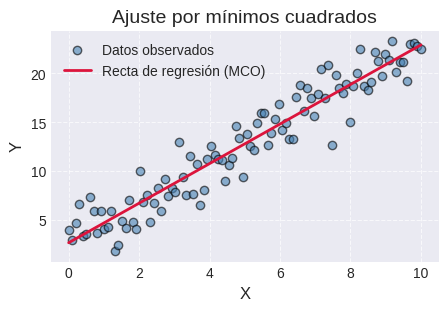

In [551]:
X_line = np.linspace(0, 10, 200).reshape(-1, 1)
Y_line = modelo.predict(X_line)

plt.figure(figsize=(5, 3))
plt.scatter(X, Y, color='steelblue', alpha=0.6, edgecolors='k', 
            label='Datos observados')
plt.plot(X_line, Y_line, color='crimson', linewidth=2, 
         label='Recta de regresión (MCO)')
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.title('Ajuste por mínimos cuadrados', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 11. Evaluación del Modelo: El Coeficiente $R^2$

El coeficiente de determinación $R^2$ mide la proporción de la varianza total de Y que es explicada por el modelo. Se calcula como:

$$
R^2 = 1 - \frac{SCE}{SCT}
$$

Donde:
- **SCE** (Suma de Cuadrados de los Errores) = $\sum (Y_i - \hat{Y}_i)^2$ (variabilidad no explicada).
- **SCT** (Suma de Cuadrados Total) = $\sum (Y_i - \bar{Y})^2$ (variabilidad total de Y).

### Interpretación:
- $R^2 = 0$: El modelo no explica nada (la recta horizontal en $\bar{Y}$ daría el mismo error).
- $R^2 = 1$: El modelo explica perfectamente todos los puntos (todos están sobre la recta).
- Valores intermedios: Por ejemplo, $R^2 = 0.85$ significa que el 85% de la variabilidad de Y es explicada por X, y el 15% restante se debe a otros factores o al azar.

En regresión simple, $R^2$ es el cuadrado del coeficiente de correlación de Pearson entre X e Y.

In [552]:
r2 = r2_score(Y, modelo.predict(X))
print(f"R² = {r2:.4f}")
print(f"El modelo explica el {r2*100:.2f}% de la variabilidad de Y.")

Y_pred = modelo.predict(X)
SCE = np.sum((Y - Y_pred)**2)
SCT = np.sum((Y - np.mean(Y))**2)
r2_manual = 1 - SCE/SCT
print(f"R² manual: {r2_manual:.4f}")

R² = 0.9147
El modelo explica el 91.47% de la variabilidad de Y.
R² manual: 0.9147


En este caso, el $R^2 \approx 0.92$ indica una relación lineal fuerte, pero no perfecta debido al ruido que añadimos.




## 12. Análisis de los Residuos

Los **residuos** ($e_i = Y_i - \hat{Y}_i$) son las diferencias entre los valores observados y los predichos. El análisis de residuos es crucial para validar los supuestos del modelo.

### Propiedades de los residuos en MCO:
- Su media es cero (por construcción, si el modelo incluye intercepto).
- Son incorrelados con X (ortogonales).
- Si el modelo es correcto, no deberían mostrar patrones evidentes.

### Gráfico de residuos vs. valores predichos:
Este gráfico nos ayuda a detectar:
- **Heterocedasticidad**: si la dispersión de los residuos cambia con el nivel de Y.
- **No linealidad**: si se observa una curva o patrón sistemático.
- **Valores atípicos**: puntos muy alejados de la banda horizontal.

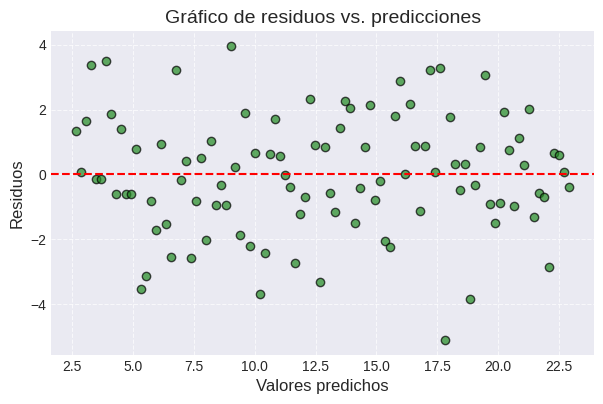

In [553]:
residuos = Y - Y_pred
plt.figure(figsize=(10*7/10, 6*7/10))
plt.scatter(Y_pred, residuos, color='forestgreen', alpha=0.7, edgecolors='k')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel('Valores predichos', fontsize=12)
plt.ylabel('Residuos', fontsize=12)
plt.title('Gráfico de residuos vs. predicciones', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Observamos que los residuos se distribuyen aleatoriamente alrededor de cero, sin forma de embudo ni patrones curvos. Esto sugiere que el modelo lineal es adecuado y que se cumple la homocedasticidad.



## 13. Predicción con Nuevos Datos

Una vez que tenemos el modelo ajustado, podemos predecir Y para nuevos valores de X. Es importante recordar que las predicciones son más fiables dentro del rango de los datos originales (interpolación) y menos fiables fuera de él (extrapolación).

In [554]:
nuevos_X = np.array([[2.5], [5.0], [7.5], [12.0]])
predicciones = modelo.predict(nuevos_X)

print("Predicciones:")
for x, y in zip(nuevos_X, predicciones):
    print(f"  X = {x[0]:.1f}  ->  Y estimado = {y[0]:.4f}")

Predicciones:
  X = 2.5  ->  Y estimado = 7.7233
  X = 5.0  ->  Y estimado = 12.7923
  X = 7.5  ->  Y estimado = 17.8613
  X = 12.0  ->  Y estimado = 26.9854


## 14. Ejemplo con un Conjunto de Datos Realista

Ahora aplicaremos la regresión lineal a un pequeño conjunto de datos: **horas de estudio vs. calificación en un examen**. Esto ayudará a ver la utilidad práctica.

In [555]:
horas = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1,1)
calificaciones = np.array([3.2, 5.1, 6.3, 7.0, 8.1, 
                           8.5, 9.2, 10.1, 11.5, 12.0])

modelo_estudio = LinearRegression()
modelo_estudio.fit(horas, calificaciones)

intercepto_est = modelo_estudio.intercept_
pendiente_est = modelo_estudio.coef_[0]

print(f"""
Ecuación: Calificación = 
{intercepto_est:.3f} + {pendiente_est:.3f} * Horas""")



Ecuación: Calificación = 
3.100 + 0.909 * Horas


In [556]:

horas_linea = np.linspace(0, 12, 100).reshape(-1,1)
pred_linea = modelo_estudio.predict(horas_linea)


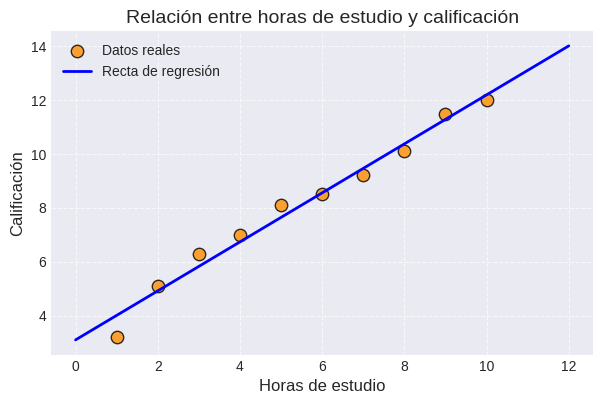

In [557]:
plt.figure(figsize=(10*7/10,6*7/10))
plt.scatter(horas, calificaciones, color='darkorange', 
            s=80, alpha=0.8, edgecolors='k', label='Datos reales')
plt.plot(horas_linea, pred_linea, color='blue', 
         linewidth=2, label='Recta de regresión')
plt.xlabel('Horas de estudio', fontsize=12)
plt.ylabel('Calificación', fontsize=12)
plt.title('Relación entre horas de estudio y calificación', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [558]:
r2_estudio = r2_score(calificaciones, modelo_estudio.predict(horas))
print(f"R² = {r2_estudio:.4f}")
print(f"""Las horas de estudio explican el 
{r2_estudio*100:.2f}% de la variabilidad de las calificaciones.""")

R² = 0.9796
Las horas de estudio explican el 
97.96% de la variabilidad de las calificaciones.


### Interpretación del ejemplo de estudio:

- **Pendiente = {pendiente_est:.3f}**: Por cada hora adicional de estudio, la calificación esperada aumenta en {pendiente_est:.3f} puntos.
- **Intercepto = {intercepto_est:.3f}**: Un estudiante que no estudia (0 horas) tendría una calificación esperada de {intercepto_est:.3f}. Tiene sentido en este contexto (podría ser la nota media por conocimientos previos).
- **R² = {r2_estudio:.4f}**: El modelo explica un {r2_estudio*100:.2f}% de la varianza, lo que indica una relación muy fuerte.

### Predicción:
¿Qué nota sacaría un estudiante que estudia 11 horas?

In [559]:
nuevas_horas = np.array([[11]])
pred_nota = modelo_estudio.predict(nuevas_horas)
print(f"Calificación estimada para 11 horas: {pred_nota[0]:.2f}")

Calificación estimada para 11 horas: 13.10


**Precaución**: 11 horas está cerca del límite superior de los datos (10 horas), pero dentro del rango observado. Si pidiéramos 20 horas, estaríamos extrapolando y la predicción podría no ser fiable.

## Regresión Lineal Múltiple

### ¿Qué es?
Es una extensión de la regresión lineal simple. En lugar de usar una sola variable independiente (X) para predecir Y, utilizamos **dos o más variables predictoras**.

### Fórmula general

$$
Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_n X_n + \varepsilon
$$

- **Y**: Variable dependiente (lo que queremos predecir).
- **X₁, X₂, …, Xₙ**: Variables independientes (predictoras).
- **β₀**: Intercepto (valor de Y cuando todas las X son 0).
- **β₁, β₂, …, βₙ**: Coeficientes parciales. Cada uno mide el cambio esperado en Y por cada aumento de una unidad en esa X, **manteniendo las demás constantes**.
- **ε**: Error o residuo.


### Notación matricial

Definimos:

- **$ \mathbf{Y} $**: vector columna de $n$ observaciones de la variable dependiente.
- **$ \mathbf{X} $**: matriz de $n \times (p+1)$ que contiene una columna de unos (para el intercepto) y las $p$ variables predictoras.
- **$ \boldsymbol{\beta} $**: vector columna de $(p+1)$ coeficientes ($\beta_0, \beta_1, \dots, \beta_p$).
- **$ \boldsymbol{\varepsilon} $**: vector columna de errores.

El modelo en forma matricial es:

$$
\mathbf{Y} = \mathbf{X} \boldsymbol{\beta} + \boldsymbol{\varepsilon}
$$



### Solución de mínimos cuadrados

La estimación de $\boldsymbol{\beta}$ que minimiza la suma de cuadrados de los errores viene dada por:

$$
\hat{\boldsymbol{\beta}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{Y}
$$

**Interpretación de los componentes:**

- $\mathbf{X}^T \mathbf{X}$: matriz de productos cruzados (y varianzas-covarianzas) de las predictoras.
- $(\mathbf{X}^T \mathbf{X})^{-1}$: inversa de esa matriz (requiere que $\mathbf{X}^T \mathbf{X}$ sea invertible, es decir, que no haya multicolinealidad perfecta).
- $\mathbf{X}^T \mathbf{Y}$: vector de productos cruzados entre cada predictora y la variable dependiente.



### Ejemplo sencillo
Queremos predecir el **precio de una vivienda** (en miles de bs) a partir de:
- **X₁**: Superficie (m²)
- **X₂**: Número de habitaciones

In [ ]:
n = 50
superficie = np.random.normal(100, 20, n).round(1) # X1: media 100 m², desv 20
habitaciones = np.random.randint(2, 6, n)          # X2: entre 2 y 5 habitaciones
# Precio real (con algo de ruido)
# Supongamos: precio = 50 + 2.5*superficie + 10*habitaciones + ruido
ruido = np.random.normal(0, 15, n)
precio = 50 + 2.5 * superficie + 10 * habitaciones + ruido
df = pd.DataFrame({'Superficie': superficie,'Habitaciones': habitaciones,
    'Precio': precio.round(1)
})
print(df.head())

   Superficie  Habitaciones  Precio
0        71.7             5   258.7
1        91.6             3   297.4
2        93.1             5   345.9
3        84.0             2   276.4
4        96.8             5   360.1


In [561]:
X = df[['Superficie', 'Habitaciones']] 
Y = df['Precio']
modelo_multiple = LinearRegression()
modelo_multiple.fit(X, Y)
print("Intercepto (β0):", modelo_multiple.intercept_.round(2))
print("Coeficientes (β1, β2):", modelo_multiple.coef_.round(2))
print("""
Ecuación: 
Precio = {:.2f} + {:.2f}*Superficie + {:.2f}*Habitaciones"""
.format(modelo_multiple.intercept_, modelo_multiple.coef_[0], 
        modelo_multiple.coef_[1]))

Intercepto (β0): 29.18
Coeficientes (β1, β2): [ 2.68 11.68]

Ecuación: 
Precio = 29.18 + 2.68*Superficie + 11.68*Habitaciones


In [562]:
predicciones = modelo_multiple.predict(X)
r2 = r2_score(Y, predicciones)
print(f"R² del modelo: {r2:.4f}")
print(f"""El modelo explica el {r2*100:.2f}% 
de la variabilidad del precio.""")

R² del modelo: 0.9554
El modelo explica el 95.54% 
de la variabilidad del precio.


### Interpretación de los coeficientes
- **β₁ (Superficie) = X.XX**: Por cada metro cuadrado adicional, el precio aumenta en X.XX miles de bs, manteniendo el número de habitaciones constante.
- **β₂ (Habitaciones) = X.XX**: Por cada habitación extra, el precio aumenta en X.XX miles de bs, manteniendo la superficie constante.

### Predicción para una nueva vivienda

In [563]:
nueva = pd.DataFrame({'Superficie': [120], 'Habitaciones': [4]})
pred = modelo_multiple.predict(nueva)
print(f"Precio estimado para 120 m² y 4 habitaciones: {pred[0]:.2f} miles de bs")

Precio estimado para 120 m² y 4 habitaciones: 397.27 miles de bs


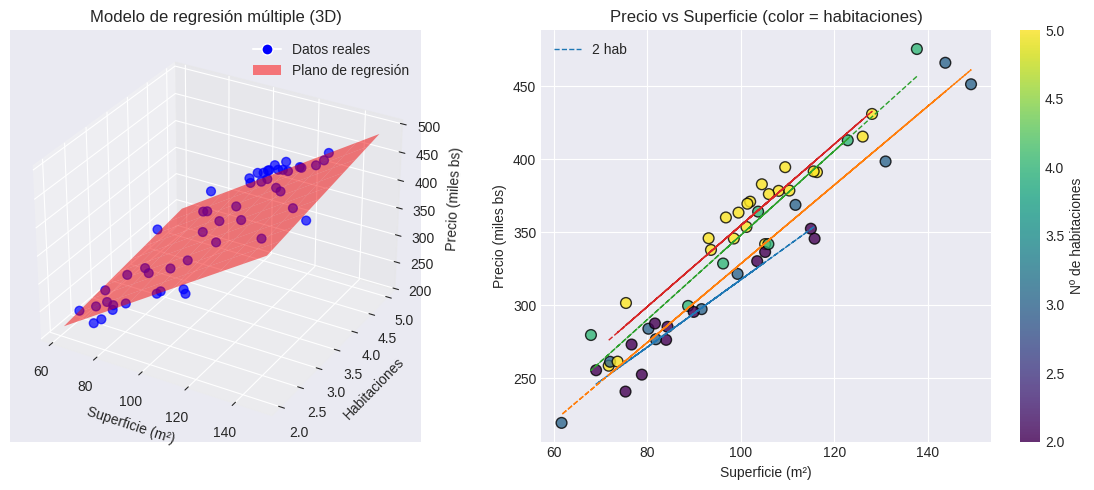

In [564]:
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')

# Puntos reales
ax1.scatter(df['Superficie'], df['Habitaciones'], df['Precio'],
            c='blue', marker='o', alpha=0.7, s=40, label='Datos reales')

S_range = np.linspace(df['Superficie'].min(), df['Superficie'].max(), 10)
H_range = np.linspace(df['Habitaciones'].min(), df['Habitaciones'].max(), 10)
S_mesh, H_mesh = np.meshgrid(S_range, H_range)
Precio_mesh = modelo_multiple.intercept_ + modelo_multiple.coef_[0] * S_mesh + modelo_multiple.coef_[1] * H_mesh

ax1.plot_surface(S_mesh, H_mesh, Precio_mesh, alpha=0.5, color='red', label='Plano de regresión')

ax1.set_xlabel('Superficie (m²)')
ax1.set_ylabel('Habitaciones')
ax1.set_zlabel('Precio (miles bs)')
ax1.set_title('Modelo de regresión múltiple (3D)')

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Datos reales',
                          markerfacecolor='blue', markersize=8),
                   Patch(facecolor='red', alpha=0.5, label='Plano de regresión')]
ax1.legend(handles=legend_elements)

ax2 = fig.add_subplot(1, 2, 2)

scatter = ax2.scatter(df['Superficie'], df['Precio'], 
                      c=df['Habitaciones'], cmap='viridis', s=60, alpha=0.8, edgecolors='k')
ax2.set_xlabel('Superficie (m²)')
ax2.set_ylabel('Precio (miles bs)')
ax2.set_title('Precio vs Superficie (color = habitaciones)')
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Nº de habitaciones')

for hab in sorted(df['Habitaciones'].unique()):
    subset = df[df['Habitaciones'] == hab]
    if len(subset) > 1:
        z = np.polyfit(subset['Superficie'], subset['Precio'], 1)
        p = np.poly1d(z)
        ax2.plot(subset['Superficie'], p(subset['Superficie']), 
                 linestyle='--', linewidth=1, label=f'{hab} hab' if hab == sorted(df['Habitaciones'].unique())[0] else "")
ax2.legend()

plt.tight_layout()
plt.show()

## 16. Limitaciones de la Regresión Lineal

- Solo captura relaciones **lineales**. Si la relación verdadera es curva (por ejemplo, Y = X²), la regresión lineal simple dará un ajuste pobre.
- Muy sensible a **valores atípicos (outliers)**. Un punto extremo puede influir desproporcionadamente en la pendiente.
- No implica **causalidad**. Una alta correlación no significa que X cause Y. Puede haber una tercera variable (confusora) que influya en ambas.
- La extrapolación fuera del rango de los datos es arriesgada.


## 17. Conclusiones

Hemos recorrido los fundamentos de la regresión lineal simple:
- **Modelo**: $Y = \beta_0 + \beta_1 X + \varepsilon$.
- **Estimación**: mínimos cuadrados ordinarios, que minimiza la suma de errores al cuadrado.
- **Interpretación**: la pendiente $\beta_1$ cuantifica el cambio esperado en Y por unidad de cambio en X.
- **Evaluación**: el coeficiente $R^2$ mide la bondad del ajuste.
- **Validación**: análisis de residuos para comprobar supuestos.

Estos conceptos son la base para modelos más avanzados como la regresión múltiple, la regresión polinómica, y muchas técnicas de machine learning.

Puedes encontrar todo el código y material adicional en mi repositorio de GitHub: [Regresión Lineal - Exposición](https://github.com/KaelAO123/Regresion-Lineal-con-Jupiter-Notebook)

¡Gracias por su atención!